# Notebook to inspect G (MASt3R) and H (MASt3R, Monocular Depth Models and Oracle)

Contents:
1. Inspect MASt3R Matches and Depthmaps
    - Fundamental Matrix and Inlier Counting
    - Compare Oracle and MASt3R Depthmaps
    - Inspect MASt3R confidence maps
2. Inspect different Monocular Depth Estimation Models 
3. Visulization about LiDAR sparsity
4. XZ (Right-Forward) Plots of Anchor-Query Estimation
5. Spatial Distribution of MASt3R pointmap prediction


### Load VBR Dataset and Model

- Change `scene_name`, `pairs_df` and `row` (index)
- To inspect depthmaps from fine-tuned model 

In [1]:
#Edit where indicated

import numpy as np
import cv2
from PIL import Image
from pyproj import Transformer
from my_vbr_utils.vbr_dataset import vbrInterpolatedDataset, load_calibration, get_paths_from_scene
from my_vbr_utils.utilities import load_scene_correspondences
import matplotlib.pyplot as plt
import pandas as pd

# --- Config and Dataset Loading ---
# Set these variables to configure your scene and utility path
scene_name = 'campus_train1'
dataset_root_dir = "/datasets/vbr_slam"
calib_path = get_paths_from_scene(dataset_root_dir, scene_name)[-1]
calib = load_calibration(calib_path)
dataset = vbrInterpolatedDataset(dataset_root_dir,scene_name)

# --- Load anchor-query pair ---
pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/campus_train1/campus_matches_inliers_fm_top10_anchors_per_query.csv')
#campus_train1 examples
row = pairs_df.iloc[30] #select a pair to use
# row = pairs_df.iloc[550]
# row = pairs_df.iloc[10]

### LOAD MAST3R MODEL AND INFERENCE UTILITIES
from mast3r.model import AsymmetricMASt3R
#load model
device = 'cuda:6'

CHECKPOINT = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
model = AsymmetricMASt3R.from_pretrained(CHECKPOINT).to(device)
# print(model)

Loaded vbrInterpolatedDataset from scene:  campus_train1
Images loaded from:  /datasets/vbr_slam/campus/campus_train1_kitti/camera_left/data
Ground Truth Poses:  /datasets/vbr_slam/campus/campus_train1/campus_train1_gt.txt


### MASt3R Matching (+Inlier Counting) and MASt3R Depthmaps

/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/model.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


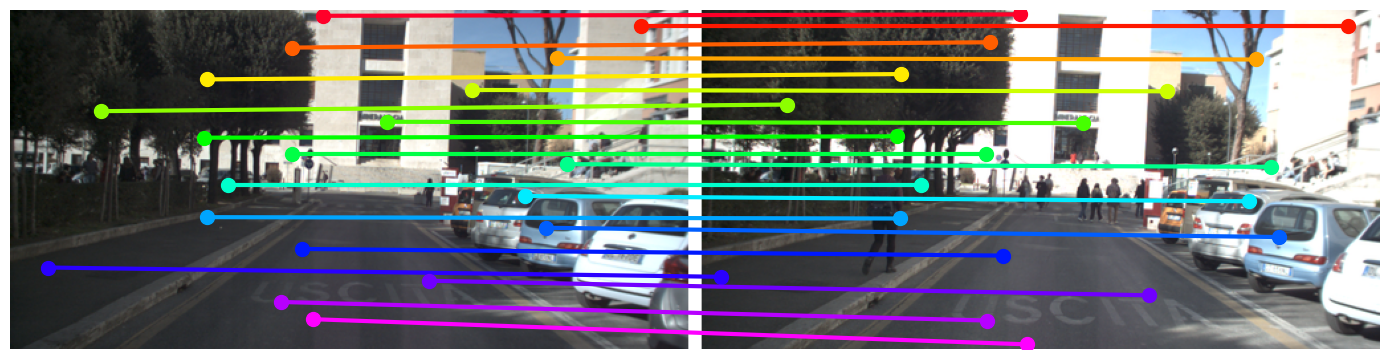

Fundamental matrix: 1661 matches, 1627 inliers, 34 outliers
Image Shaoe:  700 1388
Mast3r image shape:  256 512


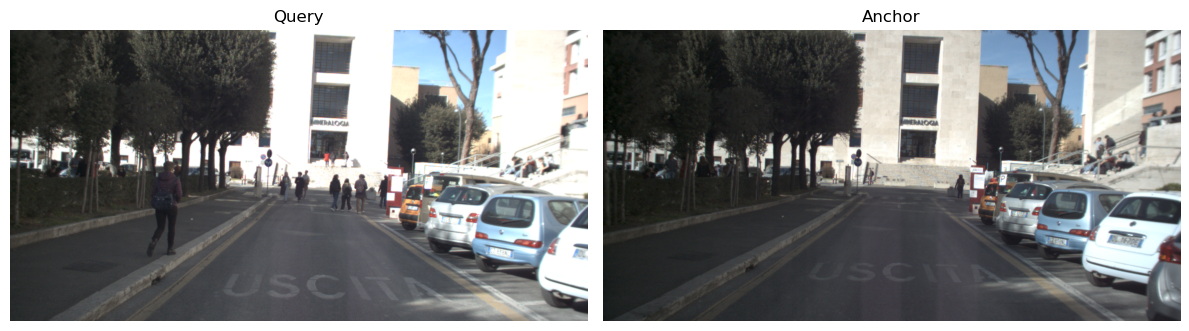

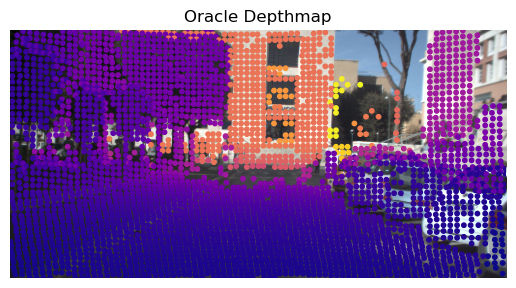

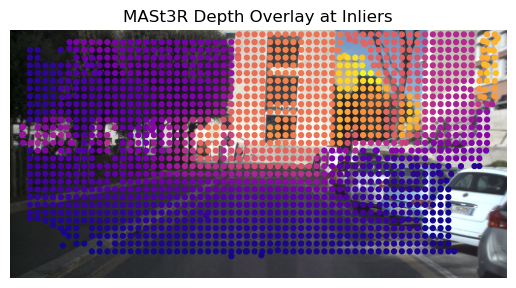

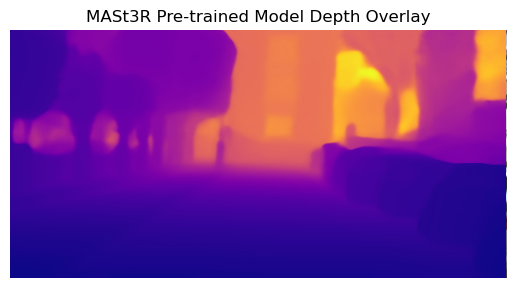

Recovered 535 matches with depth
Number of inlier matches: 535


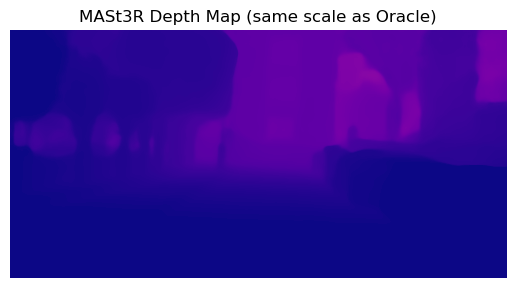

Total elements in scene_map: 393216
Number of NaN values: 382719
Percentage of NaN values: 97.33%


In [ ]:
from my_utils.plotting import show_image_pair, plot_pointclouds_top_view
from scipy.spatial.transform import Rotation as Rscipy
from my_utils.mast3r_utils import get_master_output, get_mast3r_image_shape,scale_intrinsics,overlap,plot_depth_overlay_on_image,plot_lidar_mast3r_matches
from my_utils.my_vbr_dataset import generate_depth_and_scene_maps
from my_utils.mast3r_utils import recompute_intrinsics


# row = pairs_df.iloc[460]
anchor_idx, query_idx = int(row['anchor_idx']), int(row['query_idx'])
anchor = dataset[anchor_idx]
query  = dataset[query_idx]
gt_pose = query['pose']

# --- Run MASt3R model and extract matches ---
output = get_master_output(
    model, device,
    anchor['image'],
    query['image'],
    visualize=True,
    verbose=False
)
matches_im0 = output[0]
matches_im1 = output[1]
pts3d_im0   = output[2]


# --- find number of inliers from the matches ---
if len(matches_im0) >= 8:
    F, mask_f = cv2.findFundamentalMat(matches_im0, matches_im1, cv2.FM_RANSAC, 1, 0.99)
    num_inliers_f = int(mask_f.sum()) if mask_f is not None else 0
    inlier_mask = mask_f.ravel().astype(bool)
    inlier_im0 = matches_im0[inlier_mask]
    inlier_im1 = matches_im1[inlier_mask]
else:
    num_inliers_f = 0
    inlier_im0 = np.empty((0, 2))
    inlier_im1 = np.empty((0, 2))
print(f"Fundamental matrix: {len(matches_im0)} matches, {num_inliers_f} inliers, {len(matches_im0) - num_inliers_f} outliers")

T_cam_lidar = calib['cam_l']['T_cam_lidar']
K = calib['cam_l']['K']
# --- LiDAR projection and image resizing ---
img = cv2.imread(anchor['image'])
H, W = img.shape[:2]
print("Image Shaoe: ", H, W)
mast3r_w, mast3r_h = get_mast3r_image_shape(W, H)
print("Mast3r image shape: ", mast3r_h, mast3r_w)
# K_new = scale_intrinsics(K, W, H, mast3r_w, mast3r_h)
K_new = recompute_intrinsics(K,(W,H),size=512)
depth_map, scene_map = generate_depth_and_scene_maps(anchor['lidar_points'], K_new, T_cam_lidar, (mast3r_h, mast3r_w))

# --- Load and show anchor/query images ---
anchor_img = Image.open(anchor['image'])
query_img = Image.open(query['image'])
show_image_pair(anchor_img, query_img, None, None)

# --- LiDAR depth overlay ---
img_orig = plt.imread(anchor['image'])
img_resized = cv2.resize(img_orig, (mast3r_w, mast3r_h))
img_resized = img_resized.astype(np.float32) / 255.0 if img_resized.dtype == np.uint8 else img_resized
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)
plot_depth_overlay_on_image(img_resized, scene_map, pixel_uv, point_size=10, alpha=1.0, title="Oracle Depthmap")


# # --- MASt3R 3D points overlay ---
# if len(matches_im0) > 0:
#     plot_depth_overlay_on_image(
#         img_resized,
#         pts3d_im0,
#         matches_im0,
#         point_size=12,
#         cmap='plasma',
#         alpha=1.0,
#         title="MASt3R Depth Overlay on all Matches"
#     )
if num_inliers_f > 0:
    plot_depth_overlay_on_image(
        img_resized,
        pts3d_im0,
        inlier_im0,
        point_size=12,
        cmap='plasma',
        alpha=1.0,
        title="MASt3R Depth Overlay at Inliers"
    )


H, W, _ = pts3d_im0.shape 
u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H)) #mast3r image shape
all_uv = np.stack([u_grid.ravel(), v_grid.ravel()], axis=-1)  # shape (H*W, 2)


if num_inliers_f > 0:
    plot_depth_overlay_on_image(
        img_resized,
        pts3d_im0,
        all_uv,
        point_size=12,
        cmap='plasma',
        alpha=1.0,
        title="MASt3R Pre-trained Model Depth Overlay"
    )

# --- Overlap between inlier keypoints and LiDAR depth map ---

matched_uv, matched_lidar_uv, matched_indices = overlap(inlier_im0, depth_map, max_pixel_dist=2)
inlier_im0 = inlier_im0[matched_indices]
inlier_im1 = inlier_im1[matched_indices]
print(f"Recovered {len(matched_uv)} matches with depth")
print(f"Number of inlier matches: {len(inlier_im0)}")


# # --- Plot top-down view of point clouds ---
# plot_pointclouds_top_view(
#     [lidar_pts, master_pts, master_pts_scaled],
#     labels=['LiDAR', 'MASt3R', 'Scaled MASt3R'],
#     colors=['blue', 'orange', 'green'],
#     title='Top-Down View: Matched LiDAR and MASt3R Points'
# )


# ---- Plotting MASt3R Depthmaps in the same scales as ground truth ---
from mpl_toolkits.axes_grid1 import make_axes_locatable
pts3d=output[2]
vmax = np.nanmax(scene_map[:,:,2])  # Use the maximum value from scene_map for scaling
vmin = np.nanmin(scene_map[:,:,2])  # Use the minimum value from scene_map for scaling

fig, ax = plt.subplots()
im = ax.imshow(pts3d[:,:,2], cmap='plasma', vmax=vmax, vmin=vmin)
ax.set_title("MASt3R Depth Map (same scale as Oracle)")
divider = make_axes_locatable(ax)
ax.axis('off')
plt.show()

total_elements = scene_map.size
nan_count = np.sum(np.isnan(scene_map))
nan_percentage = (nan_count / total_elements) * 100

print(f"Total elements in scene_map: {total_elements}")
print(f"Number of NaN values: {nan_count}")
print(f"Percentage of NaN values: {nan_percentage:.2f}%")



# ---- Comparing overlap between Oracle and MASt3R depthmaps ----
# 2. Find valid comparison pixels (where both have valid depth)
valid_mask = np.isfinite(scene_map).all(axis=2) & np.isfinite(pts3d_im0).all(axis=2)

# 3. Vector depth error
depth_error = pts3d_im0[valid_mask] - scene_map[valid_mask]

# 4. Calculate statistics of the error
mean_depth_error = np.mean(depth_error, axis=0)
std_depth_error = np.std(depth_error, axis=0)
max_depth_error = np.max(depth_error, axis=0)
print(mean_depth_error)

# --- Visualize the valid mask ---
plt.imshow(valid_mask, cmap='gray')  # Display the mask as a grayscale image
plt.title("Valid Mask (White = Valid)")
plt.colorbar()
plt.show()

# --- Count the number of valid elements ---
num_valid_elements = np.sum(valid_mask)
print(f"Number of valid elements: {num_valid_elements}")
total_elements = valid_mask.size
print(f"Total elements: {total_elements}")
print(f"Percentage of valid elements: {(num_valid_elements / total_elements) * 100:.2f}%")
print(f"Number of valid lidar in depth map: {len(u)}")

## Monocular Depth Estimation Models

Change `depthanything_depthmaps`, `depthpro_depthmaps` and `zoedepth_depthmaps` to root directory where depthmaps were generated. 

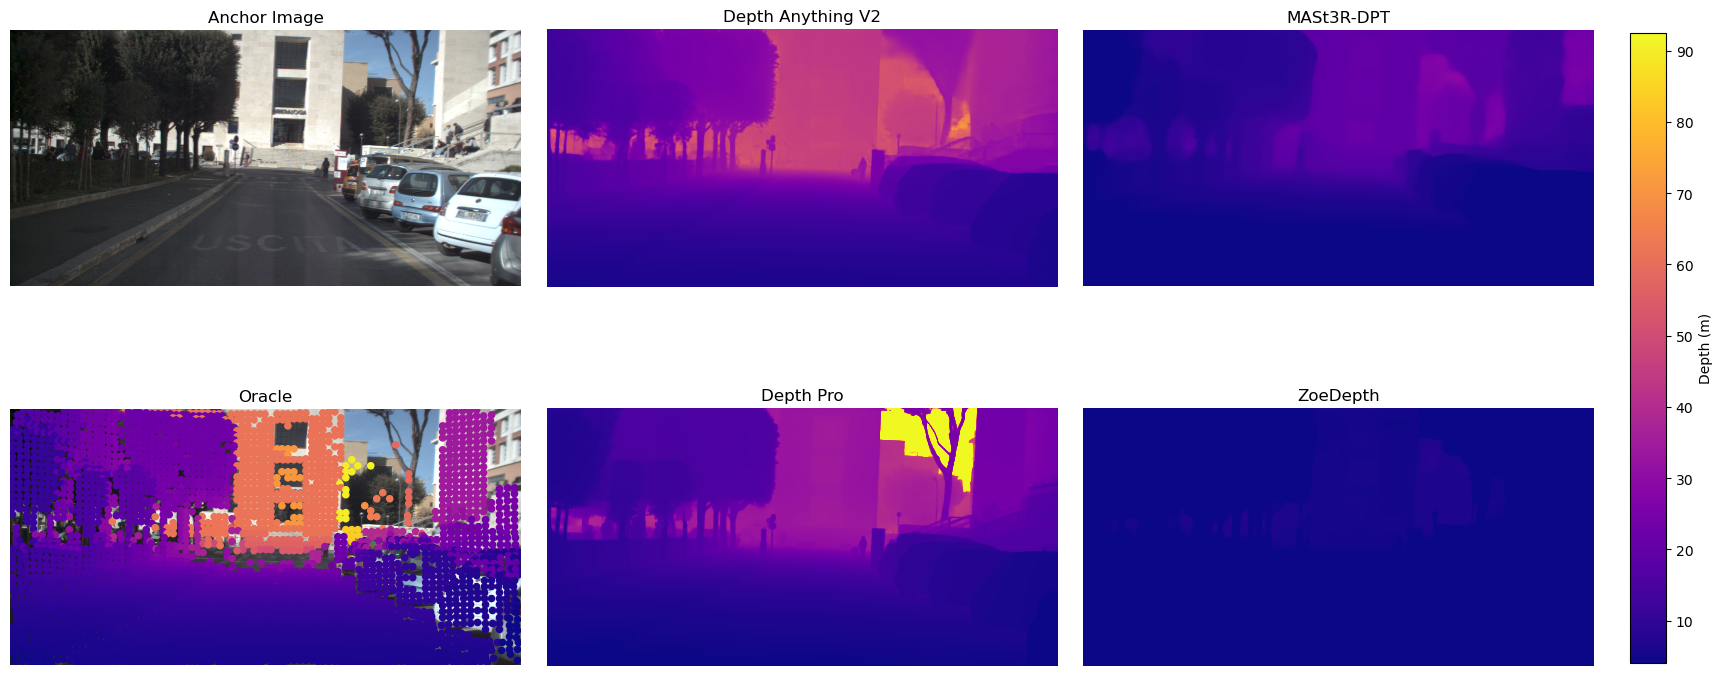

In [17]:
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)
pts3d=output[2]
vmax = np.nanmax(scene_map[:,:,2])  # Use the maximum value from scene_map for scaling
vmin = np.nanmin(scene_map[:,:,2])  # Use the minimum value from scene_map for scaling


depthanything_depthmaps = f"/home/bjangley/VPR/depthanything_80/{scene_name}/{str(anchor_idx).zfill(10)}.npy"
depthpro_depthmaps=f"/home/bjangley/VPR/depthpro_vbr/{scene_name}/{str(anchor_idx).zfill(10)}.npy"
zoedepth_depthmaps=f"/home/bjangley/VPR/zoedepth_vbr/{scene_name}/{str(anchor_idx).zfill(10)}.npy"

def plot_depth_overlay_on_axes(ax, img, scene_map, pixel_uv, cmap='plasma', alpha=1.0, point_size=40, vmin=None, vmax=None):
    """Overlay depth values from scene_map onto given matplotlib Axes."""
    u = pixel_uv[:, 0]
    v = pixel_uv[:, 1]
    depth = scene_map[v, u][:, 2]
    im = ax.imshow(img, origin='upper')
    scatter = ax.scatter(u, v, c=depth, cmap=cmap, s=point_size,
                         alpha=alpha, vmin=vmin, vmax=vmax)
    return scatter

# --- Anchor image ---
anchor_img = cv2.imread(anchor['image'])
anchor_img = cv2.cvtColor(anchor_img, cv2.COLOR_BGR2RGB)

# --- Valid LiDAR points ---
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)

# Depth maps
mast3r_depth = pts3d[:, :, 2]
depthanything = np.load(depthanything_depthmaps)
depthpro = np.load(depthpro_depthmaps)
zoedepth = np.load(zoedepth_depthmaps)

# Scaling from LiDAR
vmin = np.nanmin(scene_map[v, u][:, 2])
vmax = np.nanmax(scene_map[v, u][:, 2])

# --- Setup grid ---
fig, axes = plt.subplots(2, 3, figsize=(18, 9))  # slightly shorter figure
fig.subplots_adjust(left=0.02, right=0.9, top=0.92, bottom=0.08,
                    wspace=0.05, hspace=0.005)  # reduce hspace

# 1. Anchor image
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title("Anchor Image")
axes[0, 0].axis("off")

# 2. DepthAnything
im_da = axes[0, 1].imshow(depthanything, cmap='plasma', vmin=vmin, vmax=vmax)
axes[0, 1].set_title("Depth Anything V2")
axes[0, 1].axis("off")

# 3. MASt3R
im_ma = axes[0, 2].imshow(mast3r_depth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[0, 2].set_title("MASt3R-DPT")
axes[0, 2].axis("off")

# 4. Oracle (LiDAR overlay)
scatter = plot_depth_overlay_on_axes(
    axes[1, 0], img_resized, scene_map, pixel_uv,
    cmap='plasma', point_size=20, alpha=1.0,
    vmin=vmin, vmax=vmax
)
axes[1, 0].set_title("Oracle")
axes[1, 0].axis("off")

# 5. DepthPro
im_dp = axes[1, 1].imshow(depthpro, cmap='plasma', vmin=vmin, vmax=vmax)
axes[1, 1].set_title("Depth Pro")
axes[1, 1].axis("off")

# 6. ZoeDepth
im_zoe = axes[1, 2].imshow(zoedepth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[1, 2].set_title("ZoeDepth")
axes[1, 2].axis("off")

# --- Shared colorbar on the right ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im_dp, cax=cbar_ax)
cbar.set_label("Depth (m)")

plt.show()

## Comparing MASt3R matches with LiDAR (perspective projection)



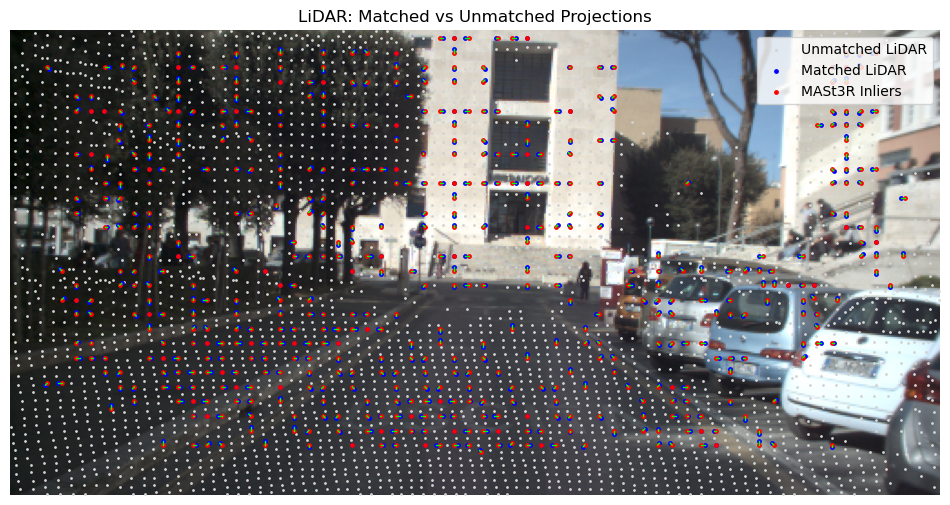

In [13]:
def plot_lidar_mast3r_matches(img, lidar_uv, matched_lidar_uv, inliers_im0, title="LiDAR: Matched vs Unmatched Projections"):
    """
    Visualize matched/unmatched LiDAR projections and MASt3R inlier matches.

    Args:
        img: Image array (background for scatter plot)
        lidar_uv: (N,2) array of all valid LiDAR-projected pixel coordinates
        matched_lidar_uv: (M,2) array of matched LiDAR pixel coordinates
        inliers_im0: (M,2) array of MASt3R inlier keypoints
          (matched to LiDAR)
        title: Plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np

    matched_lidar_uv_set = set(map(tuple, matched_lidar_uv))
    mask_matched = np.array([tuple(uv) in matched_lidar_uv_set for uv in lidar_uv])
    lidar_matched_uv = lidar_uv[mask_matched]
    lidar_unmatched_uv = lidar_uv[~mask_matched]
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    if len(lidar_unmatched_uv) > 0:
        plt.scatter(lidar_unmatched_uv[:, 0], lidar_unmatched_uv[:, 1], c='lightgray', s=1, label='Unmatched LiDAR')
    if len(lidar_matched_uv) > 0:
        plt.scatter(lidar_matched_uv[:, 0], lidar_matched_uv[:, 1], c='blue', s=6, label='Matched LiDAR')
    if len(inliers_im0) > 0:
        plt.scatter(inliers_im0[:, 0], inliers_im0[:, 1], c='red', s=6, label='MASt3R Inliers')
        # Draw lines between inlier keypoints and matched LiDAR
        for match_uv, lidar_uv_ in zip(inliers_im0, matched_lidar_uv):
            plt.plot([match_uv[0], lidar_uv_[0]], [match_uv[1], lidar_uv_[1]], color='lime', linewidth=1)
    plt.title(title)
    plt.axis('off')
    plt.legend()
    plt.show()


# Prepare lidar_uv as before
v_all, u_all = np.where(np.isfinite(depth_map))
lidar_uv = np.stack((u_all, v_all), axis=-1)

plot_lidar_mast3r_matches(
    img_resized,
    lidar_uv,
    matched_lidar_uv,
    inlier_im0
)

## XZ Plots

Scale estimated for v3 (L1 centroid scale): 2.8779133560351298
Scale estimated for v3 (L1 centroid scale): [2.16183832 2.25433933 3.13192318]
Scale estimated for v3 (L1 centroid scale): 2.8274568036572187
Scale estimated for v4 (per-axis L1 scale): [2.07827   2.1244912 2.9732988]
Scale estimated for ICP (Umeyama): 2.981283484834726


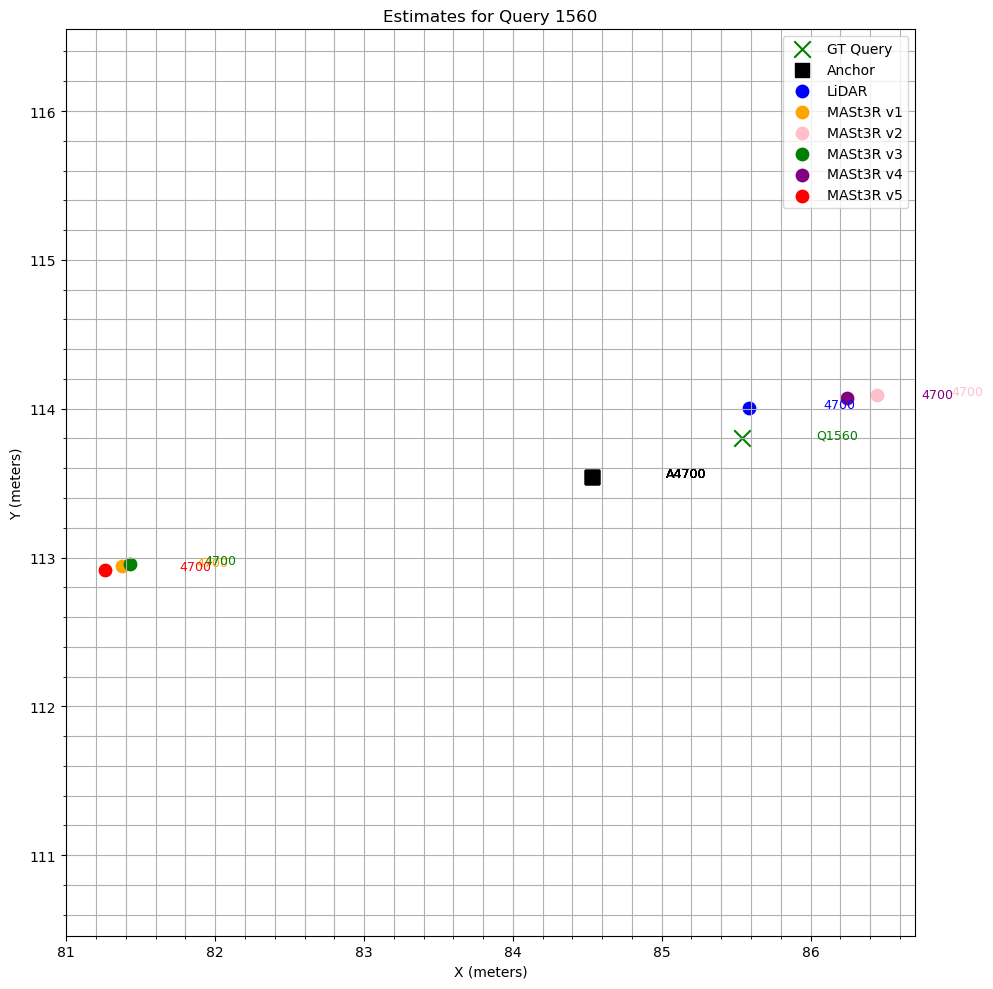

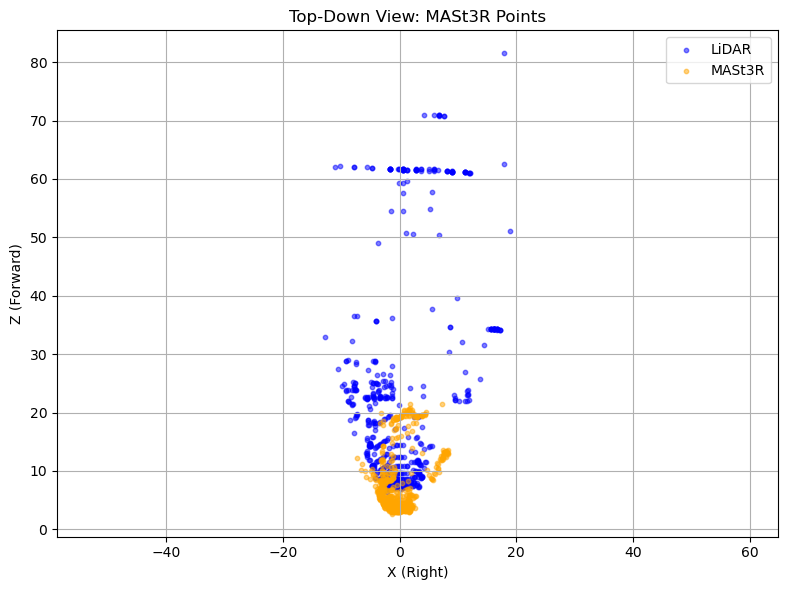

In [15]:
# Compute all localizations for the loaded anchor-query pair

from my_utils.scaling import compute_scaled_points
from my_utils.transformations import se3_to_pose, pose_to_se3
from my_utils.mast3r_utils import solve_pnp

T_base_cam = calib['cam_l']['T_base_cam']

# --- Prepare inlier 3D-2D correspondences ---
if len(inlier_im0) >= 4:
    mast3r_pts = pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)]
    lidar_pts = scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int)]
    inlier_2d = inlier_im1.astype(np.float32)
else:
    mast3r_pts = np.empty((0, 3))
    lidar_pts = np.empty((0, 3))
    inlier_2d = np.empty((0, 2))

T_anchor_local = pose_to_se3(anchor['pose'])

# --- PnP from MASt3R ---
T_query_anchor_mast3r = solve_pnp(mast3r_pts, inlier_2d, K_new) if len(mast3r_pts) >= 4 else None
if T_query_anchor_mast3r is not None:
    T_m_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_mast3r)
    pose_m = se3_to_pose(T_m_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- PnP from LiDAR ---
T_query_anchor_lidar = solve_pnp(lidar_pts, inlier_2d, K_new) if len(lidar_pts) >= 4 else None
if T_query_anchor_lidar is not None:
    T_l_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_lidar)
    pose_l = se3_to_pose(T_l_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled v3 (L1 centroid scale) ---
mast3r_pts_scaled_v1, scale_v1 = compute_scaled_points('v1', mast3r_pts, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v1 is not None:
    print(f"Scale estimated for v3 (L1 centroid scale): {scale_v1}")
T_query_anchor_scaled_v1 = solve_pnp(mast3r_pts_scaled_v1, inlier_2d, K_new) if mast3r_pts_scaled_v1.size > 0 else None
if T_query_anchor_scaled_v1 is not None:
    T_s3_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v1)
    pose_s1 = se3_to_pose(T_s3_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled v3 (L1 centroid scale) ---
mast3r_pts_scaled_v2, scale_v2 = compute_scaled_points('v2', mast3r_pts, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v2 is not None:
    print(f"Scale estimated for v3 (L1 centroid scale): {scale_v2}")
T_query_anchor_scaled_v2 = solve_pnp(mast3r_pts_scaled_v2, inlier_2d, K_new) if mast3r_pts_scaled_v2.size > 0 else None
if T_query_anchor_scaled_v2 is not None:
    T_s3_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v2)
    pose_s2 = se3_to_pose(T_s3_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]


# --- MASt3R scaled v3 (L1 centroid scale) ---
mast3r_pts_scaled_v3, scale_v3 = compute_scaled_points('v3', mast3r_pts, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v3 is not None:
    print(f"Scale estimated for v3 (L1 centroid scale): {scale_v3}")
T_query_anchor_scaled_v3 = solve_pnp(mast3r_pts_scaled_v3, inlier_2d, K_new) if mast3r_pts_scaled_v3.size > 0 else None
if T_query_anchor_scaled_v3 is not None:
    T_s3_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v3)
    pose_s3 = se3_to_pose(T_s3_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled v4 (per-axis L1 scale) ---
mast3r_pts_scaled_v4, scale_v4 = compute_scaled_points('v4', mast3r_pts, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v4 is not None:
    print(f"Scale estimated for v4 (per-axis L1 scale): {scale_v4}")
T_query_anchor_scaled_v4 = solve_pnp(mast3r_pts_scaled_v4, inlier_2d, K_new) if mast3r_pts_scaled_v4.size > 0 else None
if T_query_anchor_scaled_v4 is not None:
    T_s4_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v4)
    pose_s4 = se3_to_pose(T_s4_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled ICP (Umeyama) ---
mast3r_pts_scaled_icp, scale_icp = compute_scaled_points('icp', mast3r_pts, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_icp is not None:
    print(f"Scale estimated for ICP (Umeyama): {scale_icp}")
T_query_anchor_scaled_icp = solve_pnp(mast3r_pts_scaled_icp, inlier_2d, K_new) if mast3r_pts_scaled_icp.size > 0 else None
if T_query_anchor_scaled_icp is not None:
    T_icp_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_icp)
    pose_icp = se3_to_pose(T_icp_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- Plot all estimates ---
from my_utils.plotting import plot_all_estimates_for_query

results_dicts = {}
# if 'pose_m' in locals() and pose_m is not None:
#     results_dicts['MASt3R'] = ({query_idx: [(anchor_idx, pose_m)]}, {'anchor': 'black', 'estimate': 'orange'})

if 'pose_l' in locals() and pose_l is not None:
    results_dicts['LiDAR'] = ({query_idx: [(anchor_idx, pose_l)]}, {'anchor': 'black', 'estimate': 'blue'})
if 'pose_s1' in locals() and pose_s1 is not None:
    results_dicts['MASt3R v1'] = ({query_idx: [(anchor_idx, pose_s1)]}, {'anchor': 'black', 'estimate': 'orange'})
if 'pose_s2' in locals() and pose_s2 is not None:
    results_dicts['MASt3R v2'] = ({query_idx: [(anchor_idx, pose_s2)]}, {'anchor': 'black', 'estimate': 'pink'})
if 'pose_s3' in locals() and pose_s3 is not None:
    results_dicts['MASt3R v3'] = ({query_idx: [(anchor_idx, pose_s3)]}, {'anchor': 'black', 'estimate': 'green'})
if 'pose_s4' in locals() and pose_s4 is not None:
    results_dicts['MASt3R v4'] = ({query_idx: [(anchor_idx, pose_s4)]}, {'anchor': 'black', 'estimate': 'purple'})
if 'pose_icp' in locals() and pose_icp is not None:
    results_dicts['MASt3R v5'] = ({query_idx: [(anchor_idx, pose_icp)]}, {'anchor': 'black', 'estimate': 'red'})

plot_all_estimates_for_query(query_idx, dataset, results_dicts, styles=None)


plot_pointclouds_top_view(
    [lidar_pts, mast3r_pts],
    labels=['LiDAR','MASt3R'],
    colors=['blue','orange'],
    title='Top-Down View: MASt3R Points'
)

## Spatial Distribution of MASt3R Depthmaps

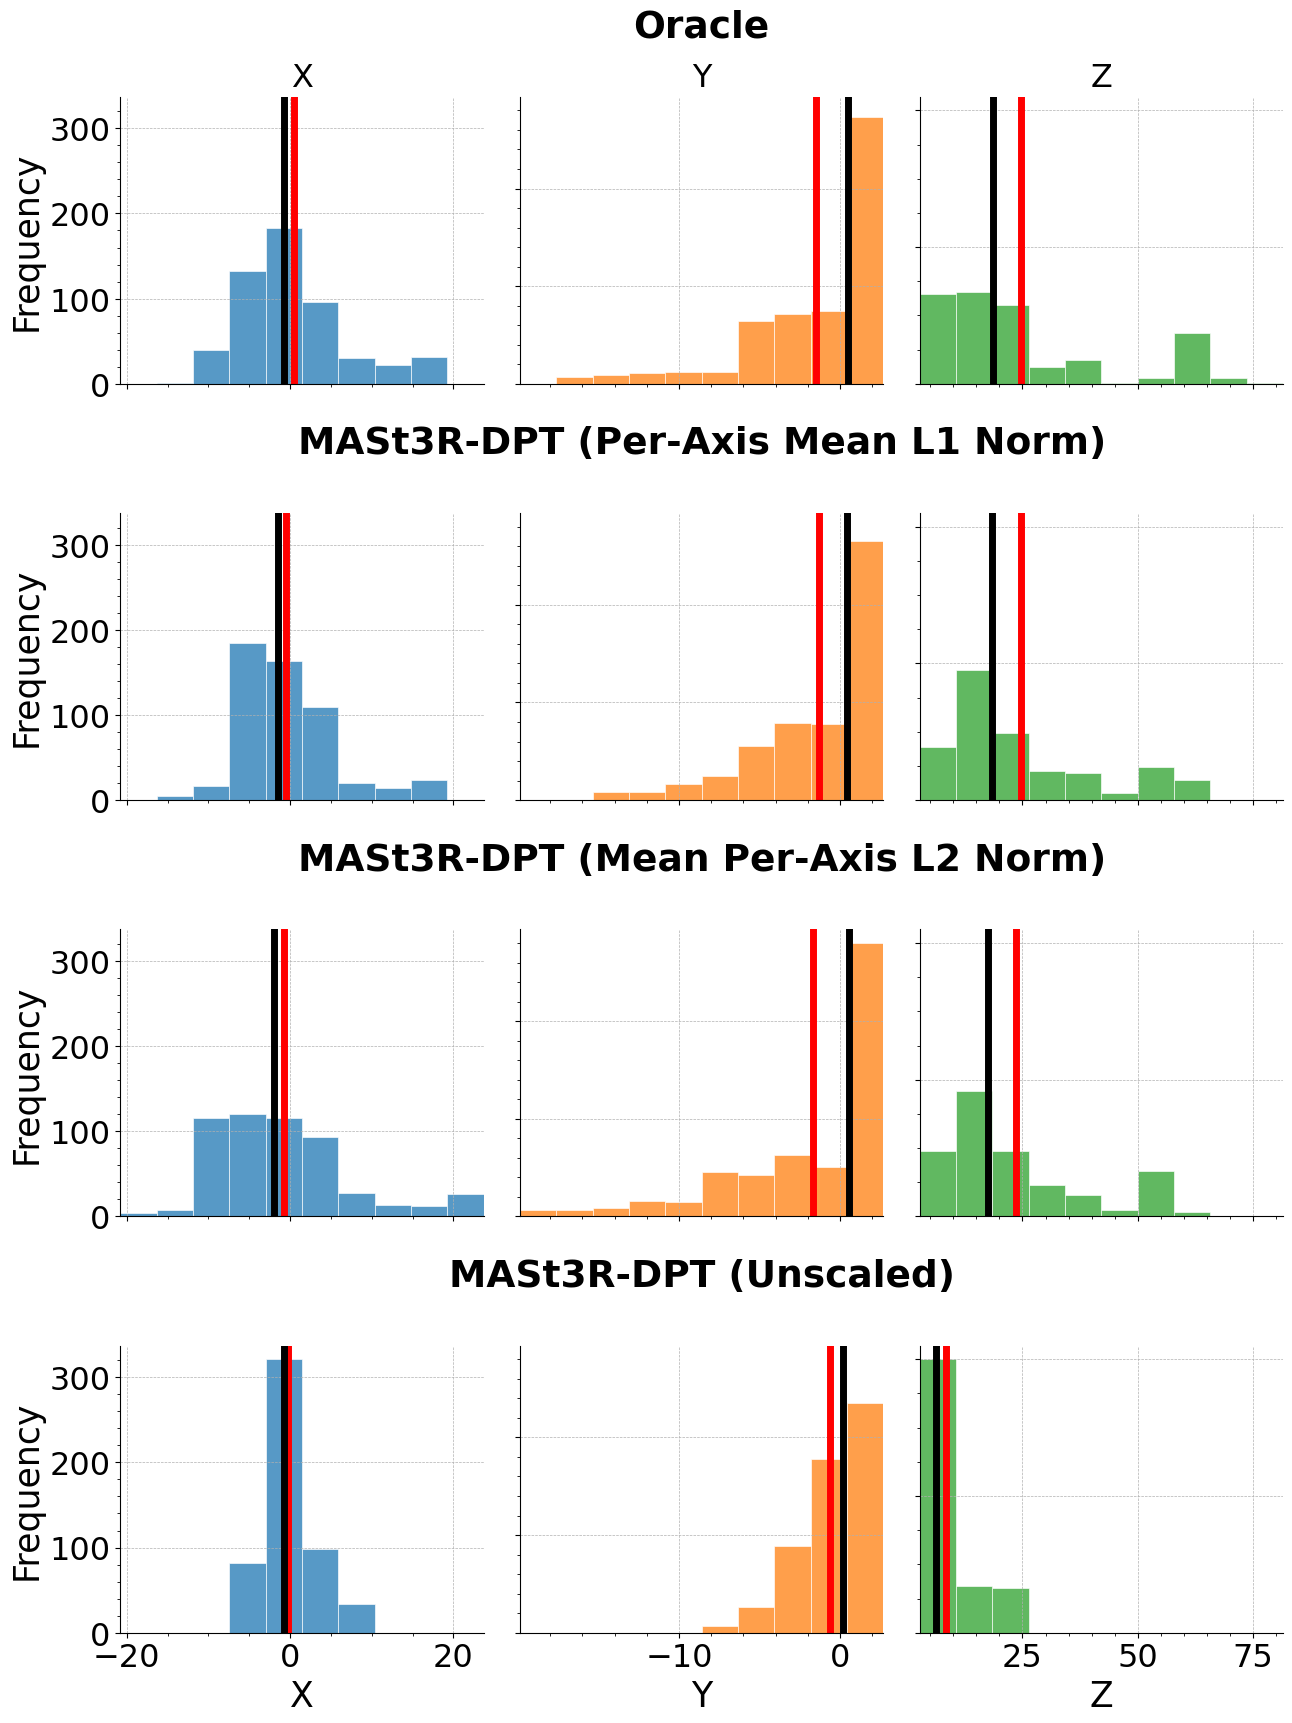

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib as mpl


# -------------------- shared scales --------------------
def compute_common_scales(point_sets, nbins=20, pad=0.02):
    """
    Return shared bin edges (per axis), x-lims, and y-max (per axis) for histograms.
    point_sets: list of (N,3) arrays; None/empty entries are ignored.
    """
    valid = [ps for ps in point_sets if ps is not None and ps.size > 0]
    if not valid:
        raise ValueError("No valid point sets provided.")

    mins = np.vstack([ps.min(axis=0) for ps in valid])
    maxs = np.vstack([ps.max(axis=0) for ps in valid])
    lo = mins.min(axis=0); hi = maxs.max(axis=0)
    span = np.maximum(hi - lo, 1e-9)
    lo -= pad * span; hi += pad * span

    bin_edges = {i: np.linspace(lo[i], hi[i], nbins + 1) for i in range(3)}
    # y-max per axis using shared bins
    y_max = {i: 0 for i in range(3)}
    for i in range(3):
        for ps in valid:
            counts, _ = np.histogram(ps[:, i], bins=bin_edges[i])
            if counts.size:
                y_max[i] = max(y_max[i], counts.max())
    xlims = {i: (lo[i], hi[i]) for i in range(3)}
    return bin_edges, xlims, y_max

# -------------------- grid plot --------------------
def plot_histograms_grid(point_sets, row_titles, *,
                         nbins=5, pad=0.02, savepath=None,
                         hspace=0.75, wspace=0.1):
    """
    Build one figure: rows = datasets, cols = X/Y/Z.
    - Axis-wise colors for bars (X=blue, Y=orange, Z=green)
    - Per-plot legend prints Mean and Median
    - Shared x/y scales across all rows for each axis
    """
    assert len(point_sets) == len(row_titles), "row_titles must match point_sets length."

    # Shared scales across all datasets
    bin_edges, xlims, y_max = compute_common_scales(point_sets, nbins=nbins, pad=pad)

    nrows = len(point_sets)
    ncols = 3  # X, Y, Z
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 6 * nrows))
    axes = np.atleast_2d(axes)

    col_labels = ['X', 'Y', 'Z']
    axis_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # X, Y, Z (classic Matplotlib palette)

    for r, pts in enumerate(point_sets):
        if pts is None or pts.size == 0:
            for c in range(ncols):
                axes[r, c].axis('off')
            continue

        for c in range(ncols):
            ax = axes[r, c]

            # Histogram with shared bins, axis-wise color
            counts = ax.hist(
                pts[:, c], bins=bin_edges[c],
                color=axis_colors[c], edgecolor='white',
                linewidth=0.6, alpha=0.75
            )[0]

            # Mean / Median lines + legend with values
            m = np.mean(pts[:, c])
            md = np.median(pts[:, c])
            ax.axvline(m,  color='red',   lw=5)
            ax.axvline(md, color='black', lw=5)

            mean_line   = Line2D([0], [0], color='red',   lw=2.2)
            median_line = Line2D([0], [0], color='black', lw=2.2)
            # ax.legend([mean_line, median_line],
            #           [f'Mean: {m:.2f}', f'Median: {md:.2f}'],
            #           loc='best', frameon=True, facecolor='white',
            #           framealpha=0.5, fontsize=20)
            # --- with this annotation (values shown, no legend box) ---
            # decide annotation anchor by column
            if c == 0:   # X axis → put in top-right
                ha, va, xpos, ypos = 'left', 'top', 0.02, 0.92
            elif c == 1: # Y axis → put in top-left (avoids overlapping lines)
                ha, va, xpos, ypos = 'left', 'top', 0.02, 0.92
            else:        # Z axis → keep top-right
                ha, va, xpos, ypos = 'right', 'top', 0.98, 0.92

            # ax.text(
            #     xpos, ypos,
            #     f'Mean: {m:.2f}\nMedian: {md:.2f}',
            #     transform=ax.transAxes,
            #     ha=ha, va=va,
            #     fontsize=25, color='black',
            #     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
            # )
            # Shared limits + styling
            ax.set_xlim(*xlims[c])
            ax.set_ylim(0, y_max[c] * 1.05)
            ax.grid(True, which='major', ls='--', lw=0.5)
            # ax.set_facecolor('#fafafa')
            ax.minorticks_on()
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Show labels only where needed
            if r != nrows - 1:
                ax.tick_params(labelbottom=False)
                ax.set_xlabel('')
            else:
                ax.set_xlabel(col_labels[c], fontsize=25)

            if c != 0:
                ax.tick_params(labelleft=False)
                ax.set_ylabel('')
            else:
                ax.set_ylabel('Frequency', fontsize=25)
            ax.tick_params(axis='both', labelsize=23) 

    # column headers on the top row (keeps X/Y/Z)
    for c in range(ncols):
        axes[0, c].set_title(col_labels[c], fontsize=23, pad=8)

    # row titles: draw as text above the middle subplot so they aren't overwritten
    for r, rt in enumerate(row_titles):
        axes[r, 1].text(
            0.5, 1.18, rt, transform=axes[r, 1].transAxes,
            ha='center', va='bottom', fontsize=27, fontweight='bold'
        )

    # give extra top/vertical space so titles don’t collide
    fig.subplots_adjust(top=0.72, hspace=0.45, wspace=wspace, bottom=0.08)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

# --- USE: build the one-shot grid ---
point_sets = [lidar_pts, mast3r_pts_scaled_v4, mast3r_pts_scaled_v3, mast3r_pts]
row_titles = ["Oracle",
    "MASt3R-DPT (Per-Axis Mean L1 Norm)",
    "MASt3R-DPT (Mean Per-Axis L2 Norm)",
    "MASt3R-DPT (Unscaled)"
]
plot_histograms_grid(point_sets, row_titles, nbins=10, pad=0)